## handling Data Effeciently And Applying The Logistic Regression

In [2]:
# First I will Import Useful libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
# Import and read The Csv and Store in Data Frame 

df=pd.read_csv('../datasets/Churn_Modelling.csv')
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7502,7503,15697844,Whitehouse,721,Spain,Female,32,10,0.00,1,1,0,136119.96,1
789,790,15653253,Pagnotto,704,Spain,Male,48,8,167997.60,1,1,1,173498.45,0
5035,5036,15712121,Chidimma,657,Spain,Male,34,5,154983.98,1,1,0,27738.01,0


In [4]:
# analyzing The data 

# df.info()
# df.describe()
#df.shape  # 10000,14

df.isnull().sum() # 0 null values 

df.sample(3)




,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1388,1389,15775295,McIntyre,630,France,Female,40,0,118633.08,1,0,1,60032.46,1
3003,3004,15801658,Summers,580,France,Male,55,6,104305.74,1,0,1,175750.21,0
3366,3367,15684010,Tuan,640,Germany,Female,74,2,116800.25,1,1,1,34130.43,0


<Axes: xlabel='Exited', ylabel='Age'>

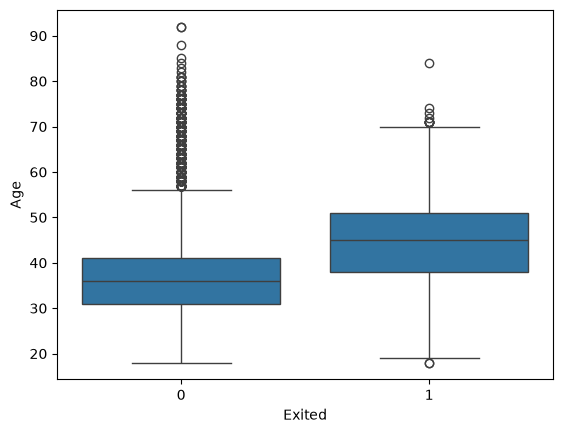

In [22]:
# df.groupby('Gender')['Exited'].value_counts()
# df.groupby('Geography')['Exited'].value_counts()

# sns.scatterplot(data=df,x='Age',y='EstimatedSalary',hue='Exited')
# # sns.scatterplot(data=df,x='Balance',y='EstimatedSalary',hue='Exited')
sns.boxplot(x="Exited", y="Age", data=df)

<Axes: xlabel='Geography', ylabel='count'>

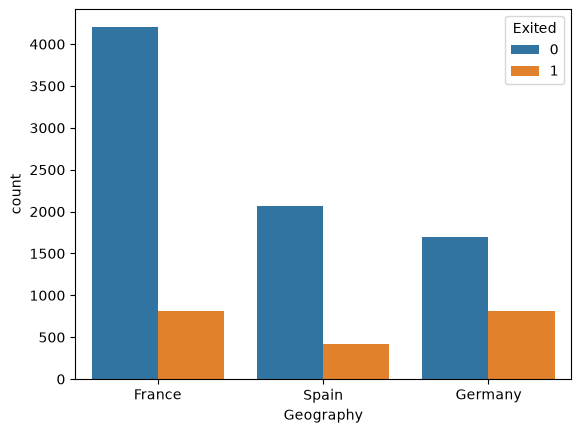

In [23]:
sns.countplot(x="Geography", hue="Exited", data=df)

<Axes: xlabel='HasCrCard', ylabel='count'>

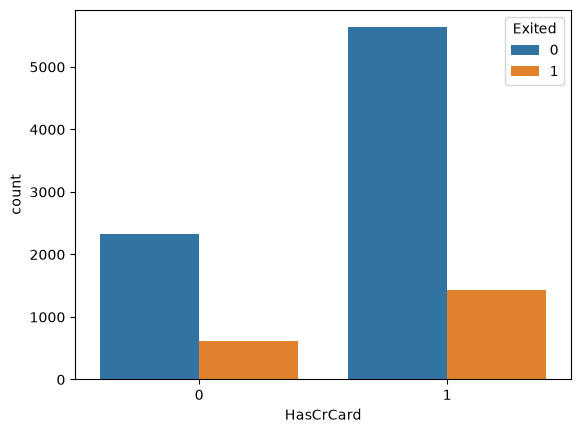

In [24]:
sns.countplot(x="HasCrCard", hue="Exited", data=df)

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

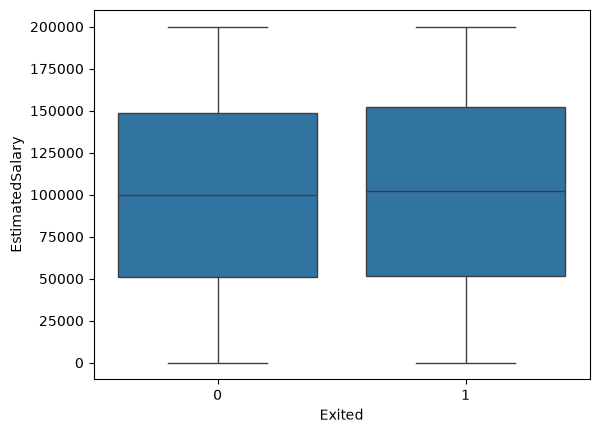

In [ ]:
sns.boxplot(x="Exited", y="EstimatedSalary", data=df)# not useful

In [26]:
pd.crosstab(df["HasCrCard"], df["Exited"], normalize="index") * 100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


In [27]:
X = df[[
    "CreditScore",
    "Geography",
    "Gender",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]]
Y = df["Exited"]

In [30]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.3)


In [32]:
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3458,3459,15748673,Nepean,770,France,Female,37,9,0.0,2,0,0,22710.72,0
5197,5198,15629744,Tan,804,France,Female,71,8,0.0,2,0,1,147995.96,0
2130,2131,15757568,Bogolyubov,704,France,Female,45,6,0.0,1,1,1,137739.45,0


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False),
         ['Geography', 'Gender'])
    ],
    remainder='passthrough'
)
X_Train_transform=transformer.fit_transform(X_Train)
print(X_Train_transform.shape)
X_Test_transform=transformer.transform(X_Test)



(7000, 11)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_Train_scalar = scaler.fit_transform(X_Train_transform)

X_Test_scalar = scaler.transform(X_Test_transform)

In [50]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_Train_scalar, Y_Train)

y_prediction = lr.predict(X_Test_scalar)

In [60]:
from sklearn.metrics import accuracy_score

model_accuracy = accuracy_score(Y_Test, y_prediction)*100

print(f'The Model Accuracy is {model_accuracy} %')



The Model Accuracy is 81.39999999999999 %


In [62]:
import pickle
pickle.dump(lr,open('LogisticRegression.pkl','wb'))